In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
from processes import *

plt.rcParams["text.usetex"] = True
plt.rcParams["figure.dpi"] = 150

In [2]:
# define parameters
L = 3
dt = 0.0001
N = 100000
D = 0.5

In [3]:
# first find domain for which optimization can help for any small resetting rate
r = 0.4
x0 = np.arange(0, L+0.1, 0.1)
l = len(x0)

In [4]:
# run underlying dynamics and get mean passage time and second moment
fpt_0, std_0 = np.zeros(l), np.zeros(l)
fpt_0[0] = 0
fpt_0[-1] = 0
std_0[0] = 0
std_0[-1] = 0

for i in range(1, l-1):
    fpt_0[i], std_0[i] = fp_N(N, dt, L, x0[i], D)

In [5]:
# calculating conditional exit times now for different starting points

fpt_0_minus, std_0_minus = np.zeros(l), np.zeros(l)
fpt_0_plus, std_0_plus = np.zeros(l), np.zeros(l)
eps0minus, eps0plus = np.zeros(l), np.zeros(l)


eps0minus[0], eps0plus[-1] = 1, 1
fpt_0_minus[0], fpt_0_minus[-1] = 0, 3
std_0_minus[0], std_0_minus[-1] = 0, 0
fpt_0_plus[0], fpt_0_plus[-1] = 3, 0
std_0_plus[0], std_0_plus[-1] = 0, 0

for i in range(1, l-1):
    fpt_0_minus[i], std_0_minus[i], fpt_0_plus[i], std_0_plus[i], eps0minus[i], eps0plus[i] = fp_conditional_N(N, dt, L, x0[i], D)

In [6]:
"""def F1(k1, k2, k3, alpha0):
    term1 = alpha0 * k2 * np.cosh(alpha0 * k2)
    term2 = 2 * np.sinh(alpha0 * k3)
    term3 = (-2 + alpha0 * k1 / np.tanh(alpha0 * k1)) * np.sinh(alpha0 * k2)
    return -2 + (1 / np.sinh(alpha0 * k1)) * (term1 + term2 + term3)

def Tr_plus(x0, L, r, D):
    alpha0 = np.sqrt(r / D)
    num = F1(x0, L - x0, L, alpha0)
    denom = 2 * r * np.sinh(alpha0 * (L - x0)) * (1 + 1 / np.sinh(alpha0 * x0))
    return num / denom

def Tr_minus(x0, L, r, D):
    alpha0 = np.sqrt(r / D)
    num = F1(L - x0, x0, L, alpha0)
    denom = 2 * r * np.sinh(alpha0 * x0) * (1 + 1 / np.sinh(alpha0 * (L - x0)))
    return num / denom

def Tr(x0, alpha0 = np.sqrt(r/D)):
    return (np.cosh(alpha0*L/2) - np.cosh(alpha0*(L/2-x0)))/(r*np.cosh(alpha0*(L/2-x0)))"""

#2nd try

def Tr(x0):
    u = x0 / L
    alpha0 = np.sqrt(r / D)
    num = np.cosh(alpha0 * L / 2)
    den = np.cosh(0.5 * alpha0 * L * (1 - 2 * u))
    return (1 / r) * (num / den - 1)

def F(x0):
    u = x0 / L
    alpha0 = np.sqrt(r / D)
    exp1 = np.exp(2 * L * alpha0)
    exp2 = np.exp(4 * u * L * alpha0)
    exp3 = np.exp(2 * u * L * alpha0)
    num = L * alpha0 * (exp1 - exp2 + (1 - 2 * u) * exp3 * (1 - exp1))
    den = 2 * (np.exp(L * alpha0) - 1) * (np.exp(L * alpha0) + exp3)
    return num / den

def Trplus(x0):
    u = x0/L
    alpha0 = np.sqrt(r / D)
    Tr_ = Tr(x0)
    exp_term = np.exp(2 * u * L * alpha0) - 1
    return Tr_ - (1 / (r * exp_term)) * F(x0)

def Trminus(x0):
    u = x0/L
    alpha0 = np.sqrt(r / D)
    Tr_ = Tr(x0)
    exp1 = np.exp(L * alpha0)
    exp2 = np.exp(2 * L * alpha0)
    exp3 = np.exp(2 * u * L * alpha0)
    return Tr_ + (exp1 / (r * (exp2 - exp3))) * F(x0)

In [7]:
# now do the same for resetting imposed

fpt_r, std_r = np.zeros(l), np.zeros(l)
fpt_r[0] = Tr(0)
fpt_r[-1] = Tr(L)
std_r[0] = 0
std_r[-1] = 0

for i in range(1, l-1):
    fpt_r[i], std_r[i] = resetting_fp_N(N, dt, L, x0[i], r, D)

In [8]:
# conditional times in reser

fpt_r_minus, std_r_minus = np.zeros(l), np.zeros(l)
fpt_r_plus, std_r_plus = np.zeros(l), np.zeros(l)
epsrminus, epsrplus = np.zeros(l), np.zeros(l)

fpt_r_minus[0], fpt_r_minus[-1] = 0, Trminus(L)
std_r_minus[0], std_r_minus[-1] = 0, 0
fpt_r_plus[0], fpt_r_plus[-1] = Trplus(0), 0
std_r_plus[0], std_r_plus[-1] = 0, 0

for i in range(1, l-1):
    fpt_r_minus[i], std_r_minus[i], fpt_r_plus[i], std_r_plus[i], epsrminus[i], epsrplus[i] = resetting_fp_conditional_N(N, dt, L, x0[i], r, D)

/var/folders/c8/m11vsrv50cv5c2b0ljtrkgtw0000gn/T/ipykernel_6706/1985626140.py:55: RuntimeWarning: divide by zero encountered in scalar divide
  return Tr_ + (exp1 / (r * (exp2 - exp3))) * F(x0)
/var/folders/c8/m11vsrv50cv5c2b0ljtrkgtw0000gn/T/ipykernel_6706/1985626140.py:46: RuntimeWarning: divide by zero encountered in scalar divide
  return Tr_ - (1 / (r * exp_term)) * F(x0)
/var/folders/c8/m11vsrv50cv5c2b0ljtrkgtw0000gn/T/ipykernel_6706/1985626140.py:46: RuntimeWarning: invalid value encountered in scalar multiply
  return Tr_ - (1 / (r * exp_term)) * F(x0)


In [9]:
# calculate CV and Lambda for underlying dynamics

def CV(std, mean):
    return std/mean
def lambd(mean0, mean_sig, CV):
    return np.sqrt(mean0**2/(2*mean_sig**2)*(1+CV**2))

CV0 = CV(std_0[1:-1], fpt_0[1:-1])
CVminus = CV(std_0_minus[1:-1], fpt_0_minus[1:-1])
lambdaminus = lambd(fpt_0[1:-1], fpt_0_minus[1:-1], CV0)
CVplus = CV(std_0_plus[1:-1], fpt_0_plus[1:-1])
lambdaplus = lambd(fpt_0[1:-1], fpt_0_plus[1:-1], CV0)

In [10]:
# find the domain in which resetting can help optimize unconditional and both conditional times

def find_points(x, y, target = 0):
    x_pts = []
    for i in range(len(y)):
        if abs(y[i] - target) < 1e-2:
            x_pts.append(x[i])
    return x_pts

T0_optimization = find_points(x0[1:-1]/L, CV0-1)
T0_minus_optimization = find_points(x0[1:-1]/L, CVminus-lambdaminus)
T0_plus_optimization = find_points(x0[1:-1]/L, CVplus-lambdaplus)

print(f"CV > 1 at {T0_optimization}")
print(f"CV- > lambda- at {T0_minus_optimization}")
print(f"CV+ > lambda+ at {T0_plus_optimization}")

CV > 1 at []
CV- > lambda- at []
CV+ > lambda+ at []


In [11]:
from scipy.interpolate import interp1d

def interpolate(x, y, point=0):
    inv_interp = interp1d(y, x, kind = 'quadratic')
    return inv_interp(point)

In [12]:
x_CV0_1 = interpolate(x0[1:len(CV0)//2+1]/L, CV0[:len(CV0)//2]-1)
x_CV0_2 = interpolate(x0[len(CV0)//2+1:-1]/L, CV0[len(CV0)//2:]-1)
x_CVminus = interpolate(x0[-12:-1]/L, CVminus[-11:]-lambdaminus[-11:])
x_CVplus = interpolate(x0[1:12]/L, CVplus[:11]-lambdaplus[:11])

print(x_CV0_1, x_CV0_2, x_CVminus, x_CVplus)

0.27503190953537565 0.7234642538639723 0.6813203917856844 0.30968338852603106


In [13]:
def CV0exact(x0):
    u = x0/L
    return np.sqrt((1 - 2*u + 2*u**2)/(3*(u - u**2)))

def CVplusexact(x0):
    u = x0/L
    return np.sqrt((2*(1+u**2))/(5*(1-u**2)))
def lambdaplusexact(x0):
    u = x0/L
    return np.sqrt((3*u*(1+u-u**2))/(2*(1-u)*(1+u)**2))

def CVminusexact(x0):
    u = x0/L
    return np.sqrt((2*(u**2 - 2*u + 2))/(5*u*(2-u)))
def lambdaminusexact(x0):
    u = x0/L
    return np.sqrt((3*(1-2*u**2+u**3))/(2*u*(2-u)**2))

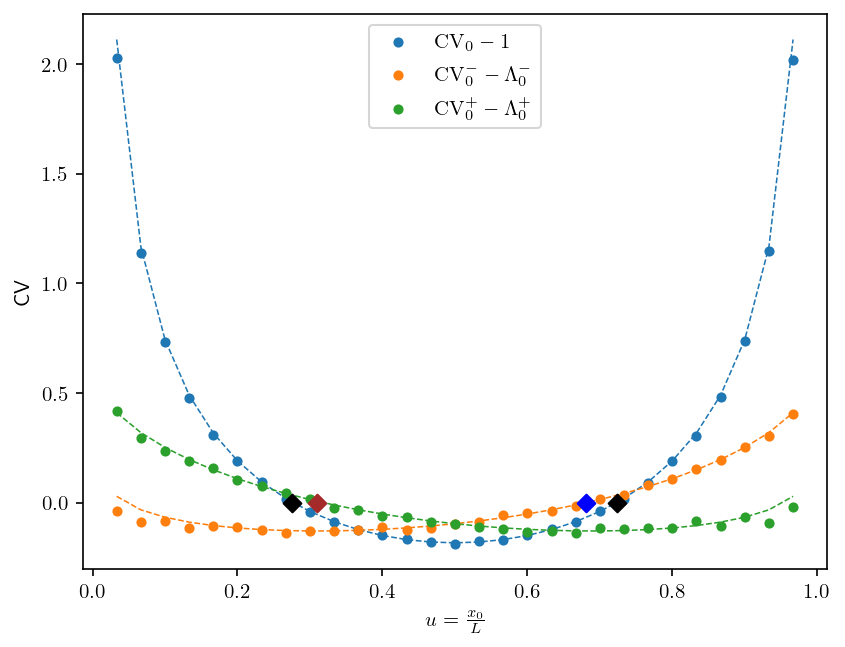

In [75]:
plt.scatter(x0[1:-1]/L, CV0-1, label = r"$\mathrm{CV}_0-1$", s = 15, zorder = 1)
plt.plot(x0[1:-1]/L, CV0exact(x0[1:-1]) - 1, '--', lw = 0.75, zorder = 0)
plt.scatter(x0[1:-1]/L, CVminus-lambdaminus, label = r"$\mathrm{CV}^-_0 - \Lambda^-_0$", s = 15, zorder = 1)
plt.plot(x0[1:-1]/L, CVminusexact(x0[1:-1]) - lambdaminusexact(x0[1:-1]), '--', lw = 0.75, zorder = 0)
plt.scatter(x0[1:-1]/L, CVplus-lambdaplus, label = r"$\mathrm{CV}^+_0 - \Lambda^+_0$", s = 15, zorder = 1)
plt.plot(x0[1:-1]/L, CVplusexact(x0[1:-1]) - lambdaplusexact(x0[1:-1]), '--', lw = 0.75, zorder = 0)

plt.scatter(x_CV0_1, 0, marker = 'D', zorder = 2, color = 'black')
plt.scatter(x_CV0_2, 0, marker = 'D', zorder = 2, color = 'black')
plt.scatter(x_CVminus, 0, marker = 'D', zorder = 2, color = 'blue')
plt.scatter(x_CVplus, 0, marker = 'D', zorder = 2, color = 'brown')

plt.xlabel(r"$u = \frac{x_0}{L}$")
plt.ylabel("CV")
plt.legend()
plt.show()

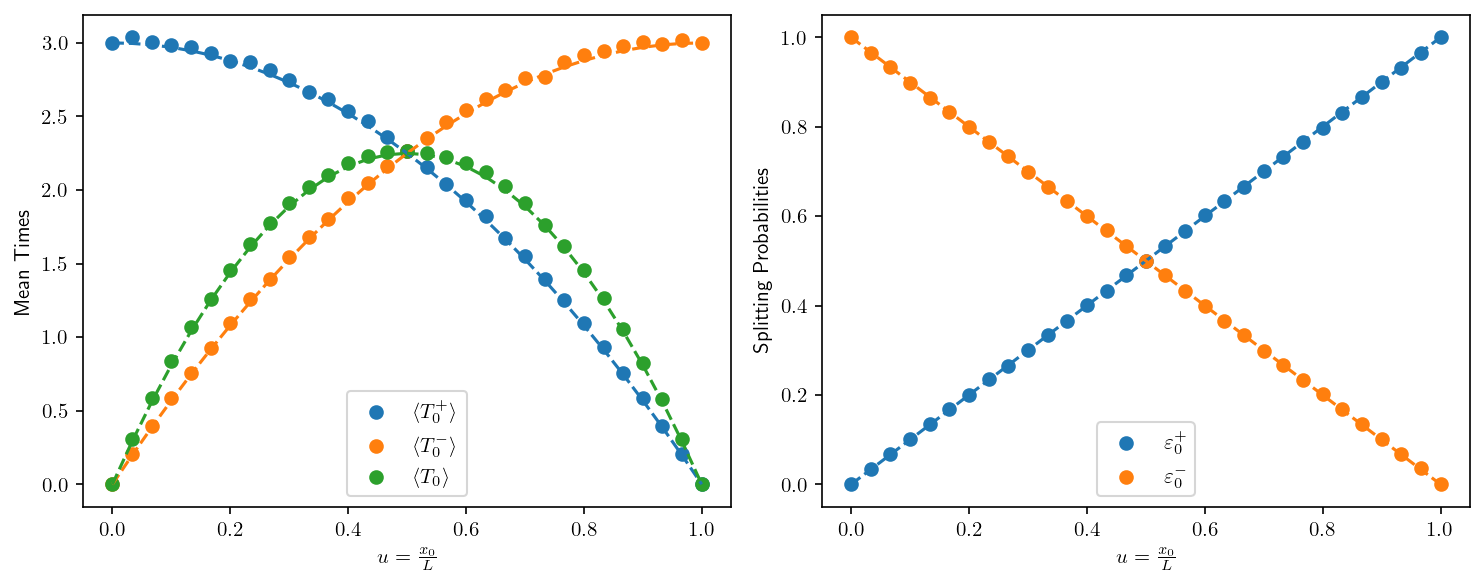

In [37]:
fig, axes = plt.subplots(1, 2, figsize = (10,4))

u = x0/L

axes[0].scatter(u, fpt_0_plus, label = r"$\langle T_0^+\rangle$")
axes[0].plot(u, (L**2/(6*D))*(1-u**2), '--')
axes[0].scatter(u, fpt_0_minus, label = r"$\langle T_0^-\rangle$")
axes[0].plot(u, (L**2/(6*D))*u*(2-u), '--')
axes[0].scatter(u, fpt_0, label = r"$\langle T_0\rangle$")
axes[0].plot(u, (L**2/(2*D))*u*(1-u), '--')
axes[0].legend()
axes[0].set_xlabel(r"$u = \frac{x_0}{L}$")
axes[0].set_ylabel(r"Mean Times")

axes[1].scatter(x0/L, eps0plus, label = r'$\varepsilon_0^+$')
axes[1].plot(x0/L, x0/L, '--')
axes[1].scatter(x0/L, eps0minus, label = r'$\varepsilon_0^-$')
axes[1].plot(x0/L, 1-x0/L, '--')
axes[1].legend(loc = 'lower center')
axes[1].set_xlabel(r"$u = \frac{x_0}{L}$")
axes[1].set_ylabel(r"Splitting Probabilities")

plt.tight_layout()

plt.show()

In [38]:
def sprobplus_exact(x0, alpha0 = np.sqrt(r/D)):
    u = x0/L
    return np.sinh(alpha0*u*L)/(np.sinh(alpha0*L*(1-u)) + np.sinh(alpha0*u*L))

def sprobminus_exact(x0, alpha0 = np.sqrt(r/D)):
    u = x0/L
    return np.sinh(alpha0*(1-u)*L)/(np.sinh(alpha0*L*(1-u)) + np.sinh(alpha0*u*L))

/var/folders/c8/m11vsrv50cv5c2b0ljtrkgtw0000gn/T/ipykernel_6706/1985626140.py:46: RuntimeWarning: divide by zero encountered in divide
  return Tr_ - (1 / (r * exp_term)) * F(x0)
/var/folders/c8/m11vsrv50cv5c2b0ljtrkgtw0000gn/T/ipykernel_6706/1985626140.py:46: RuntimeWarning: invalid value encountered in multiply
  return Tr_ - (1 / (r * exp_term)) * F(x0)
/var/folders/c8/m11vsrv50cv5c2b0ljtrkgtw0000gn/T/ipykernel_6706/1985626140.py:55: RuntimeWarning: divide by zero encountered in divide
  return Tr_ + (exp1 / (r * (exp2 - exp3))) * F(x0)


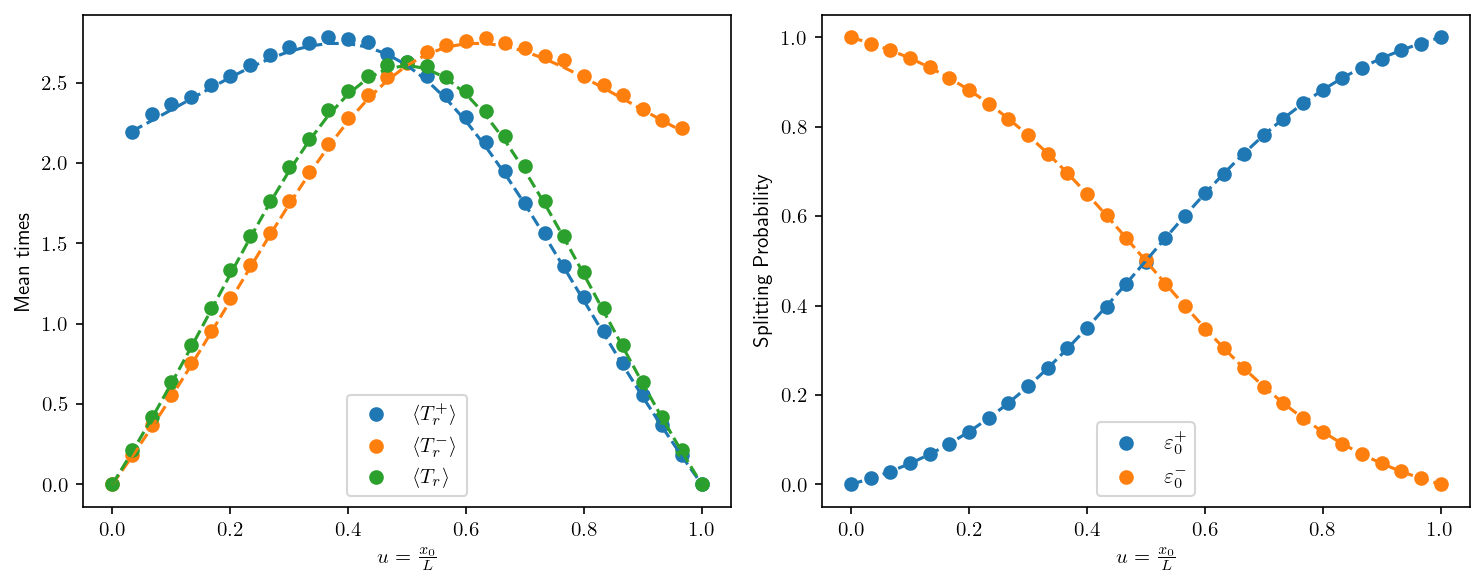

In [40]:
fig, axes = plt.subplots(1, 2, figsize = (10,4))

ax1, ax2 = axes[0], axes[1]

ax1.scatter(x0/L, fpt_r_plus, label = r"$\langle T_r^+\rangle$")
ax1.plot(x0/L, Trplus(x0),'--')
ax1.scatter(x0/L, fpt_r_minus, label = r"$\langle T_r^-\rangle$")
ax1.plot(x0/L, Trminus(x0),'--')
ax1.scatter(x0/L, fpt_r, label = r"$\langle T_r\rangle$")
ax1.plot(x0/L, Tr(x0), '--')
ax1.set_xlabel(r"$u = \frac{x_0}{L}$")
ax1.set_ylabel("Mean times")
ax1.legend(loc = 'lower center')

epsrplus_exact = sprobplus_exact(x0)
epsrminus_exact = sprobminus_exact(x0)
epsrplus[-1], epsrminus[0] = 1, 1
ax2.scatter(x0/L, epsrplus, label = r'$\varepsilon_0^+$')
ax2.plot(x0/L, epsrplus_exact, '--')
ax2.scatter(x0/L, epsrminus, label = r'$\varepsilon_0^-$')
ax2.plot(x0/L, epsrminus_exact, '--')
ax2.set_xlabel(r"$u = \frac{x_0}{L}$")
ax2.set_ylabel(r"Splitting Probability")
ax2.legend(loc = 'lower center')

plt.tight_layout()

plt.show()

In [17]:
# knowing the domains for optimization plot for different restart rates with the same initial point

r_opt = np.arange(0, 4, 0.1)
x0minus = 0.8*L
x0plus = 0.15*L
D = 0.2

In [18]:
# unconditional with resetting for differnet restart rates and for each starting point

fptr_opt_minusx0 = []
stdr_opt_minusx0 = []

for i in range(len(r_opt)):
    fpt, std = resetting_fp_N(N, dt, L, x0minus, r_opt[i], D)
    fptr_opt_minusx0.append(fpt)
    stdr_opt_minusx0.append(std)

fptr_opt_minusx0 = np.array(fptr_opt_minusx0)
stdr_opt_minusx0 = np.array(stdr_opt_minusx0)

fptr_opt_plusx0 = []
stdr_opt_plusx0 = []

for i in range(len(r_opt)):
    fpt, std = resetting_fp_N(N, dt, L, x0plus, r_opt[i], D)
    fptr_opt_plusx0.append(fpt)
    stdr_opt_plusx0.append(std)

fptr_opt_plusx0 = np.array(fptr_opt_plusx0)
stdr_opt_plusx0 = np.array(stdr_opt_plusx0)

In [19]:
# now conditional times

#for x0 = 0.15L
fpt_r_minus_minusx0, std_r_minus_minusx0 = [], []
fpt_r_plus_minusx0, std_r_plus_minusx0 = [], []

for i in range(len(r_opt)):
    fpt_minus, std_minus, fpt_plus, std_plus = resetting_fp_conditional_N(N, dt, L, x0minus, r_opt[i], D)
    fpt_r_minus_minusx0.append(fpt_minus)
    std_r_minus_minusx0.append(std_minus)
    fpt_r_plus_minusx0.append(fpt_plus)
    std_r_plus_minusx0.append(std_plus)

fpt_r_minus_minusx0 = np.array(fpt_r_minus_minusx0)
std_r_minus_minusx0 = np.array(std_r_minus_minusx0)
fpt_r_plus_minusx0 = np.array(fpt_r_plus_minusx0)
std_r_plus_minusx0 = np.array(std_r_plus_minusx0)

# for x0 = 0.8L

fpt_r_minus_plusx0, std_r_minus_plusx0 = [], []
fpt_r_plus_plusx0, std_r_plus_plusx0 = [], []

for i in range(len(r_opt)):
    fpt_minus, std_minus, fpt_plus, std_plus = resetting_fp_conditional_N(N, dt, L, x0plus, r_opt[i], D)
    fpt_r_minus_plusx0.append(fpt_minus)
    std_r_minus_plusx0.append(std_minus)
    fpt_r_plus_plusx0.append(fpt_plus)
    std_r_plus_plusx0.append(std_plus)

fpt_r_minus_plusx0 = np.array(fpt_r_minus_plusx0)
std_r_minus_plusx0 = np.array(std_r_minus_plusx0)
fpt_r_plus_plusx0 = np.array(fpt_r_plus_plusx0)
std_r_plus_plusx0 = np.array(std_r_plus_plusx0)

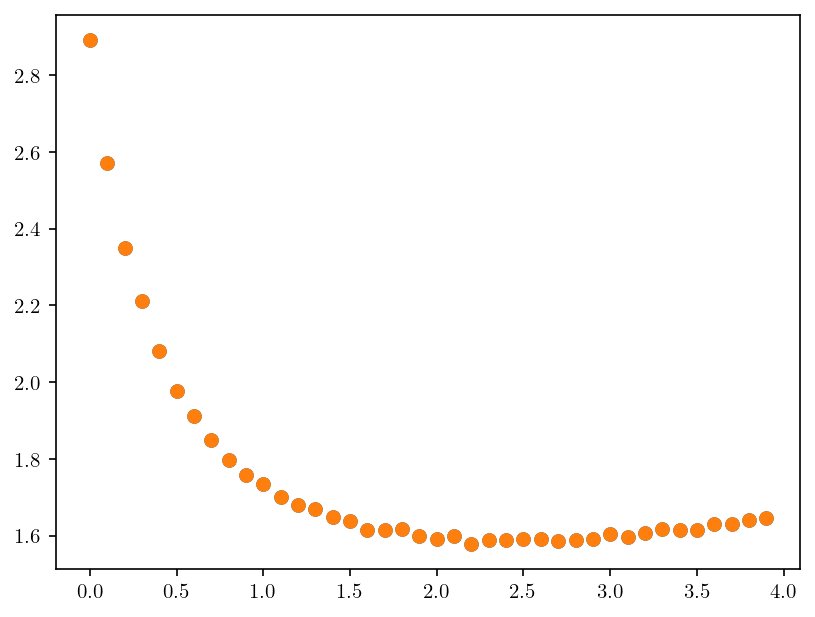

In [24]:
plt.scatter(r_opt, fptr_opt_plusx0)
plt.scatter(r_opt, fptr_opt_plusx0)